In [1]:
import matplotlib.pyplot as plt
import numpy as np
import ast

import pandas as pd
from datasets import load_dataset
#loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval (x) if pd.notna(x) else x)

#ast.literal_eval() takes a string (or AST node) and converts it into the corresponding Python object [].
#It comes from the built-in ast module.

In [13]:
df = df[df['job_title_short'] == 'Data Analyst'].copy()
df_exploded = df.explode('job_skills')
skill_stats = df_exploded.groupby('job_skills').agg(
    skill_count = ('job_skills', 'count'),
    median_salary = ('salary_year_avg', 'median')
)
skills_stats = skill_stats.sort_values(by='skill_count', ascending=False).head(10)
skills_stats

,skill_count,median_salary
job_skills,,
sql,92428,92500.0
excel,66860,84479.0
python,57190,98500.0
tableau,46455,95000.0
power bi,39380,90000.0
r,29996,92527.5
sas,27998,90000.0
powerpoint,13822,85000.0
word,13562,80000.0


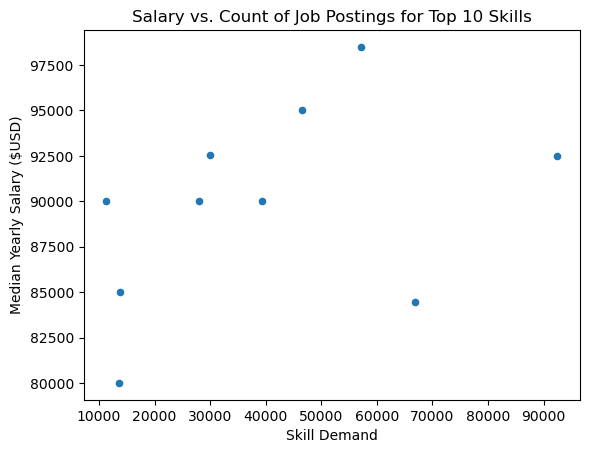

In [24]:
skills_stats.plot(kind='scatter', x = 'skill_count', y = 'median_salary')
plt.title('Salary vs. Count of Job Postings for Top 10 Skills')
plt.xlabel('Skill Demand')
plt.ylabel('Median Yearly Salary ($USD)')
plt.show()

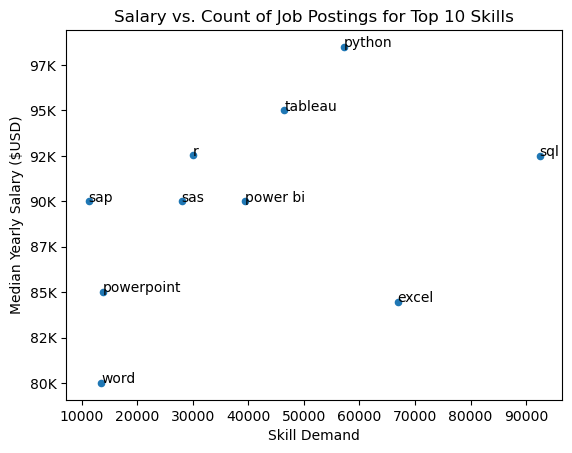

In [29]:
import matplotlib.ticker as ticker

ax = skills_stats.plot(kind='scatter', x='skill_count', y='median_salary')

plt.title('Salary vs. Count of Job Postings for Top 10 Skills')
plt.xlabel('Skill Demand')
plt.ylabel('Median Yearly Salary ($USD)')

# Format y-axis to show values in 'K'
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}K'))

# Add labels to points
for i, txt in enumerate(skills_stats.index):
    plt.text(
        skills_stats['skill_count'].iloc[i],
        skills_stats['median_salary'].iloc[i],
        txt
    )

plt.show()